# **Importing Libraries and Mounting Drive**

- Google Drive Mounting.
- Importing all necessary libraries for data analysis and data visualization.

In [ ]:
# #Import drive to get data
# from google.colab import drive
# drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#For the purpose of reproducability, use this code block instead
import os

# Set base directory relative to the notebook's location
BASE_DIR = os.getcwd()
DATA_DIR = os.path.join(BASE_DIR, "Data")

In [ ]:
#library packages for data visualization and analysis. I was too lazy to make a function to call my packages.
!pip install osmnx
import geopandas as gpd
import pandas as pd
import folium
import matplotlib.pyplot as plt
import osmnx as ox
import seaborn as sns
import math
import branca.colormap as cm
import plotly.express as px

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.4/104.4 kB 3.2 MB/s eta 0:00:00


# **Data Reading and Cleaning**

- Load in California Tax Credit Allocation Committee Data bounded within Berkeley and Oakland, California.
- Load in cleaned East Bay Lyft Station Data
- View Data to ensure a clean load.
- Make a data copy to conduct analysis, set a consistent coordinate reference system.

In [ ]:
#Import the tcac data for Oakland and Berkeley that I made in another notebook
tcac_path = os.path.join(DATA_DIR, "raw/tcac_oak_berk.gpkg")
tcac_oak_berk = gpd.read_file(tcac_path)

In [ ]:
#display data to see if it is all there
tcac_oak_berk

,fips,fips_bg,county_name,region,pct_above_200_pov,pct_bachelors_plus,pct_employed,home_value,math_prof,read_prof,...,pct_asian,pct_black,pct_hispanic,pct_poc,pct_asian_cty,pct_black_cty,pct_hispanic_cty,pct_poc_cty,pov_seg_flag,geometry
0,06001400100,None,Alameda,Bay Area Region,0.912195,0.855738,0.784858,1802100.0,0.683709,0.711517,...,0.149321,NaN,NaN,0.319005,0.319851,0.096275,0.233206,0.71764,NaN,"MULTIPOLYGON (((-122.24691 37.88536, -122.2419..."
1,06001400200,None,Alameda,Bay Area Region,0.903966,0.839766,0.759462,1930000.0,0.665117,0.708944,...,0.122312,NaN,0.093645,0.327281,0.319851,0.096275,0.233206,0.71764,NaN,"MULTIPOLYGON (((-122.25742 37.8431, -122.2562 ..."
2,06001400300,None,Alameda,Bay Area Region,0.889960,0.807848,0.848602,1850900.0,0.431718,0.493813,...,0.106338,0.091496,NaN,0.412432,0.319851,0.096275,0.233206,0.71764,0.0,"MULTIPOLYGON (((-122.26416 37.84, -122.26186 3..."
3,06001400400,None,Alameda,Bay Area Region,0.820271,0.807012,0.856718,1398400.0,0.553012,0.614790,...,0.096018,NaN,0.137429,0.398180,0.319851,0.096275,0.233206,0.71764,NaN,"MULTIPOLYGON (((-122.2618 37.84179, -122.2613 ..."
4,06001400500,None,Alameda,Bay Area Region,0.748166,0.681416,0.762106,1313500.0,0.528160,0.585979,...,0.080063,NaN,0.145735,0.556253,0.319851,0.096275,0.233206,0.71764,0.0,"MULTIPOLYGON (((-122.26941 37.84811, -122.2683..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145,06001424002,None,Alameda,Bay Area Region,0.756250,0.529317,0.786496,1176300.0,0.462152,0.493704,...,0.105365,0.245465,0.179081,0.593593,0.319851,0.096275,0.233206,0.71764,NaN,"MULTIPOLYGON (((-122.28679 37.85218, -122.2814..."
146,06001981900,None,Alameda,Bay Area Region,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0.319851,0.096275,0.233206,0.71764,NaN,"MULTIPOLYGON (((-122.34225 37.80556, -122.3338..."
147,06001982000,None,Alameda,Bay Area Region,NaN,NaN,NaN,1028400.0,0.227492,0.234690,...,NaN,NaN,NaN,NaN,0.319851,0.096275,0.233206,0.71764,NaN,"MULTIPOLYGON (((-122.31321 37.7953, -122.30774..."
148,06001982100,None,Alameda,Bay Area Region,0.689655,NaN,0.660000,NaN,0.669748,0.725244,...,0.394904,NaN,0.171065,0.670610,0.319851,0.096275,0.233206,0.71764,NaN,"MULTIPOLYGON (((-122.26633 37.87419, -122.2653..."


In [ ]:
#make a copy to maintain the original
tcac_map_copy = tcac_oak_berk.copy()

In [ ]:
#Turn my copy into a gdf, turn crs to 4326 for future visualization
tcac_map_copy = gpd.GeoDataFrame(tcac_map_copy, geometry="geometry")

if tcac_map_copy.crs is None:
    tcac_map_copy = tcac_map_copy.set_crs(epsg=4326)

tcac_map_copy = tcac_map_copy.to_crs(epsg=4326)


In [ ]:
#Load station data from other notebook
lyft_path = os.path.join(DATA_DIR, "raw/station_year_counts.geojson")
station_year_gdf = gpd.read_file(lyft_path)

In [ ]:
#inspect data to see if everything is there
station_year_gdf

,Station ID,Station Name,City,Year,Trip Count,Latitude,Longitude,geometry
0,BK-A3,College Ave at Alcatraz Ave,Berkeley,2020,672,37.851376,-122.252523,POINT (-122.25252 37.85138)
1,BK-A3,College Ave at Alcatraz Ave,Berkeley,2021,1098,37.851376,-122.252523,POINT (-122.25252 37.85138)
2,BK-A3,College Ave at Alcatraz Ave,Berkeley,2022,1106,37.851376,-122.252523,POINT (-122.25252 37.85138)
3,BK-A3,College Ave at Alcatraz Ave,Berkeley,2023,1153,37.851376,-122.252523,POINT (-122.25252 37.85138)
4,BK-A3,College Ave at Alcatraz Ave,Berkeley,2024,1847,37.851376,-122.252523,POINT (-122.25252 37.85138)
...,...,...,...,...,...,...,...,...
742,OK-N6,Webster St at 2nd St,Oakland,2024,2375,37.795195,-122.273970,POINT (-122.27397 37.79519)
743,OK-N6,Webster St at 2nd St,Oakland,2025,2982,37.795195,-122.273970,POINT (-122.27397 37.79519)
744,OK-N7,Webster St at 2nd St,Oakland,2020,689,37.795194,-122.273969,POINT (-122.27397 37.79519)
745,OK-N7,Webster St at 2nd St,Oakland,2021,234,37.795194,-122.273969,POINT (-122.27397 37.79519)


In [ ]:
#create data copy to make sure original data stays clean
lyft_data = station_year_gdf.copy()

In [ ]:
#turn into a geodataframe so that I can visualize my data later
lyft_gdf = gpd.GeoDataFrame(
    lyft_data,
    geometry=gpd.points_from_xy(
        lyft_data["Longitude"],
        lyft_data["Latitude"]
    ),
    crs="EPSG:4326"
)

# **Merge Data**
- Merge and clean data.

In [ ]:
#Spatially join the data together so I can start the visualization
lyft_tcac_merged = gpd.sjoin(
    lyft_gdf,
    tcac_map_copy,
    how="left",
    predicate="within"   # switch to "intersects" if needed. I had been having this problem with my sjoin and found that within works better.
)

In [ ]:
#Inspect data to see if merge worked properly
lyft_tcac_merged.head()

,Station ID,Station Name,City,Year,Trip Count,Latitude,Longitude,geometry,index_right,fips,...,pct_below_pov,pct_asian,pct_black,pct_hispanic,pct_poc,pct_asian_cty,pct_black_cty,pct_hispanic_cty,pct_poc_cty,pov_seg_flag
0,BK-A3,College Ave at Alcatraz Ave,Berkeley,2020,672,37.851376,-122.252523,POINT (-122.25252 37.85138),141,06001423800,...,NaN,0.097688,NaN,NaN,0.263295,0.319851,0.096275,0.233206,0.71764,NaN
1,BK-A3,College Ave at Alcatraz Ave,Berkeley,2021,1098,37.851376,-122.252523,POINT (-122.25252 37.85138),141,06001423800,...,NaN,0.097688,NaN,NaN,0.263295,0.319851,0.096275,0.233206,0.71764,NaN
2,BK-A3,College Ave at Alcatraz Ave,Berkeley,2022,1106,37.851376,-122.252523,POINT (-122.25252 37.85138),141,06001423800,...,NaN,0.097688,NaN,NaN,0.263295,0.319851,0.096275,0.233206,0.71764,NaN
3,BK-A3,College Ave at Alcatraz Ave,Berkeley,2023,1153,37.851376,-122.252523,POINT (-122.25252 37.85138),141,06001423800,...,NaN,0.097688,NaN,NaN,0.263295,0.319851,0.096275,0.233206,0.71764,NaN
4,BK-A3,College Ave at Alcatraz Ave,Berkeley,2024,1847,37.851376,-122.252523,POINT (-122.25252 37.85138),141,06001423800,...,NaN,0.097688,NaN,NaN,0.263295,0.319851,0.096275,0.233206,0.71764,NaN


In [ ]:
#Looking at all columns to see what I can drop and keep for my analysis.
lyft_tcac_merged.columns

Index(['Station ID', 'Station Name', 'City', 'Year', 'Trip Count', 'Latitude',
       'Longitude', 'geometry', 'index_right', 'fips', 'fips_bg',
       'county_name', 'region', 'pct_above_200_pov', 'pct_bachelors_plus',
       'pct_employed', 'home_value', 'math_prof', 'read_prof', 'grad_rate',
       'pct_not_frpm', 'pct_above_200_pov_median', 'pct_bachelors_plus_median',
       'pct_employed_median', 'home_value_median', 'math_prof_median',
       'read_prof_median', 'grad_rate_median', 'pct_not_frpm_median',
       'env_burden_flag', 'oppscore', 'oppcat', 'pct_below_pov', 'pct_asian',
       'pct_black', 'pct_hispanic', 'pct_poc', 'pct_asian_cty',
       'pct_black_cty', 'pct_hispanic_cty', 'pct_poc_cty', 'pov_seg_flag'],
      dtype='object')

In [ ]:
# Confirming key fields for data
lyft_tcac_merged[[
    "Station ID",
    "Station Name",
    "Year",
    "Trip Count",
    "oppscore",
    "oppcat"
]].head()

,Station ID,Station Name,Year,Trip Count,oppscore,oppcat
0,BK-A3,College Ave at Alcatraz Ave,2020,672,8.0,Highest Resource
1,BK-A3,College Ave at Alcatraz Ave,2021,1098,8.0,Highest Resource
2,BK-A3,College Ave at Alcatraz Ave,2022,1106,8.0,Highest Resource
3,BK-A3,College Ave at Alcatraz Ave,2023,1153,8.0,Highest Resource
4,BK-A3,College Ave at Alcatraz Ave,2024,1847,8.0,Highest Resource


In [ ]:
#Making sure my data types are in the correct format for analysis
lyft_tcac_merged.dtypes

,0
Station ID,object
Station Name,object
City,object
Year,int32
Trip Count,int32
Latitude,float64
Longitude,float64
geometry,geometry
index_right,int64
fips,object


In [ ]:
#creating a cleaned copy of my data and then dropping all unnecessary columns that don't work for my analysis
merged_clean = lyft_tcac_merged.copy()

merged_clean = merged_clean.drop(
    columns=[
        'fips_bg', 'county_name', 'region',
        'pct_above_200_pov', 'pct_bachelors_plus', 'pct_employed', 'home_value',
        'math_prof', 'read_prof', 'grad_rate', 'pct_not_frpm',
        'pct_above_200_pov_median', 'pct_bachelors_plus_median',
        'pct_employed_median', 'home_value_median', 'math_prof_median',
        'read_prof_median', 'grad_rate_median', 'pct_not_frpm_median',
        'env_burden_flag',
        'pct_asian_cty', 'pct_black_cty', 'pct_hispanic_cty', 'pct_poc_cty',
        'pov_seg_flag'
    ],
    errors='ignore'   # prevents crashes if any column is missing
)

In [ ]:
#Inspecting my columns
merged_clean.columns

Index(['Station ID', 'Station Name', 'City', 'Year', 'Trip Count', 'Latitude',
       'Longitude', 'geometry', 'index_right', 'fips', 'oppscore', 'oppcat',
       'pct_below_pov', 'pct_asian', 'pct_black', 'pct_hispanic', 'pct_poc'],
      dtype='object')

In [ ]:
#Inspecting my data types
merged_clean.dtypes

,0
Station ID,object
Station Name,object
City,object
Year,int32
Trip Count,int32
Latitude,float64
Longitude,float64
geometry,geometry
index_right,int64
fips,object


In [ ]:
#Seeing if I have a oppscore for all my data
merged_clean["oppscore"].isna().sum()

np.int64(0)

In [ ]:
#making sure all my data have a geometry column so I can do spatial analysis
merged_clean['geometry'].isna().sum()

np.int64(0)

# **Mapping**
- Create Base Map using folium.
- Sort data by year to create individual layers for visual representation.
- Add colorblind friendly color palette to the map for TCAC opportunity score for visualizations.
- Normalize data for a clean data range.
- Use branca colormap for map visualizations.
- Clean visualizations for missing data (in this case 2 tracts in West Oakland with missing opportunity score #)

### *Folium Documentation*
- https://python-visualization.github.io/folium/latest/#


### *Branca.colormap Documentation*

- https://python-visualization.github.io/branca/colormap.html
- https://python-visualization.github.io/branca/

In [ ]:
# Create map to house my data
base_map = folium.Map(
    location=[37.8, -122.27], #centering my data on Oakland and Berkeley
    zoom_start=12, #Set zoom to be able to see both
    tiles="cartodbpositron" #gives me a grey-ish base map
)

# Set polygons to the same crs and sets a geometry buffer
tcac_polygons = tcac_map_copy.copy().to_crs(epsg=4326)
tcac_polygons["geometry"] = tcac_polygons["geometry"].buffer(0)

In [ ]:
# gives me my colors for my map, gives me a nice pastel. I chose this also for a colorblind-friendly palette that shows a sequential change in opportunity score.
colormap = cm.LinearColormap(
    colors=["#D55E00", "#F0E442", "#009E73", "#0072B2"],
    vmin=tcac_polygons["oppscore"].min(),
    vmax=tcac_polygons["oppscore"].max()
)
#Need to set the little legend so people can understand which polygon color is which at a glance
colormap.caption = "TCAC Opportunity Score"

#Need to do custom positioning because foliums default is in the corner and I can't read it.
colormap.width = 400
colormap.height = 25 #changing this to control the legend height because it is illegible as its base settings.
#gives the legend a smoother look instead of a gradient, which was hard to read by changing the bins.
colormap = colormap.to_step(n=5) #5 bins seems to work best as it is about 2 values per bin

colormap.add_to(base_map)


In [ ]:
# Add tcac polygons first so they go underneath the circles.
#I was having a lot of problems with this and had to rewrite my code to get the order right.
folium.GeoJson(
    tcac_polygons,
    name="TCAC Opportunity",

    tooltip=folium.GeoJsonTooltip(
        fields=["oppscore", "oppcat", "pct_poc"], #using opp score and cat in conjuntion with poc to understand how race and opportunity are linked
        aliases=["Score:", "Category:", "% POC:"] #rename to be human readable
    ),

    popup=folium.GeoJsonPopup(
        fields=["oppscore", "oppcat", "pct_poc"] #pop-up for the interactive portion of the map will use these fields. Should be easy to view
    ),

    style_function=lambda feature: { #passes the opportunity score value and adds it to the base map with its respective color
        "fillColor": (
            colormap(feature["properties"]["oppscore"])
            if feature["properties"].get("oppscore") is not None
            and not math.isnan(feature["properties"]["oppscore"])
            else "#999999" #This is important. Two West Oakland census tracts are null and messed up the visualization of my data. This turns those values grey and ignores the null values
        ),
        "color": "black", #All of the polygon boundary settings
        "weight": 0.4,
        "fillOpacity": 0.4,
    },

    highlight_function=lambda x: { #This governs how a polygon interacts with your cursor to make the viewed polygon more visible
        "weight": 2, #increases the weight of the border
        "color": "blue", #makes polygons blue
        "fillOpacity": 0.7 #makes less opaque
    }

).add_to(base_map)

In [ ]:
# Add Lyft data after TCAC to have it on top.
#Took me way to long to figure this out
max_trips = merged_clean["Trip Count"].max()
#For loop to sort merged data by year
for year in sorted(merged_clean["Year"].unique()):
    year_layer = folium.FeatureGroup(name=f"Lyft {year}") # I wanted a year toggle layer so that viewers can visually understand the difference between ridership and opp score over time
    year_data = merged_clean[merged_clean["Year"] == year]

    for _, row in year_data.iterrows():
        radius = (row["Trip Count"] / max_trips) * 15
#Sets the lyft bike data to the respective geometry to be displayed on the map
        folium.CircleMarker( #using a circle marker, I was playing around with the idea of a heatmap but that seemed abstract for this visualization
            location=[row.geometry.y, row.geometry.x],
            radius=radius,
            fill=True,
            fill_opacity=0.85,
            popup=( #pop-up configuration
                f"<b>{row['Station Name']}</b><br>" #truthfully had no clue how to make this work, had to get some help
                f"Year: {row['Year']}<br>" #Uses Python f strings to insert HTML-formatted text into the map, lots of documentation reading and a little AI help with this one
                f"Trips: {row['Trip Count']}<br>" #basically becomes Trips: "Trip Count", etc.
                f"Opportunity: {row['oppcat']}"
            )
        ).add_to(year_layer)

    year_layer.add_to(base_map)

In [ ]:
# Sets layer control to bottom left instead of top right because I was having issues displaying the legend and the layer control at the same time. Folium legends default top right and I don't know how to fix that other than this method which is pretty simple.
folium.LayerControl(
    collapsed=False,
    position="bottomleft"   # moves away from legend, puts it in the bottom left instead
).add_to(base_map)

# display map
base_map

In [ ]:
#null value opportunity score
tcac_polygons["oppscore"].isna().sum()

np.int64(2)

In [ ]:
## To download, remove the hashes

# base_map.save("tcac_lyft_map.html")
# #Downloading my map
# from google.colab import files
# files.download("tcac_lyft_map.html")

# **Data Visualization: Charts and Graphs**


Used Plotly Express to make my graphs and charts interactive. The documentation I used can be found here: https://plotly.com/python/plotly-express/
- Creates opportunity score summary and total ridership by station counts

- Graph 1: Total Ridership by Opportunity Category

- Graph 2: Average Ridership by Opportunity Category (Need to change to the mean)

- Graph 3: Ridership vs. Opportunity Score

- Graph 4 (Interactive): Ridership Trends

- Graph 5 (Interactive): Ridership by Year and Opportunity Category


In [ ]:
#Creates total sums for trip counts by TCAC opportunity category group
opp_summary = merged_clean.groupby("oppcat", as_index=False).agg({
    "Trip Count": "sum"
})

In [ ]:
#Creates a count for unique station ID in each opportunity category
station_counts = merged_clean.groupby("oppcat")["Station ID"].nunique().reset_index()
#renames the count to number of stations
station_counts.columns = ["oppcat", "num_stations"]
#Merges the summary of station counts with opportunity categories
opp_summary = opp_summary.merge(station_counts, on="oppcat")
#Calculates the averages of trips and creates a new column for the averages
opp_summary["avg_trips_per_station"] = (
    opp_summary["Trip Count"] / opp_summary["num_stations"]
)
#Display the table to make sure everything worked properly
opp_summary

,oppcat,Trip Count,num_stations,avg_trips_per_station
0,High Resource,308042,38,8106.368421
1,Highest Resource,167027,24,6959.458333
2,Low Resource,211755,58,3650.948276
3,Moderate Resource,265837,30,8861.233333


Graph 1: Total Ridership by Opportunity Category

In [ ]:
#Creating an order for my categories so that data is displayed in sequential order.
category_order = ["Low Resource", "Moderate Resource", "High Resource", "Highest Resource"]

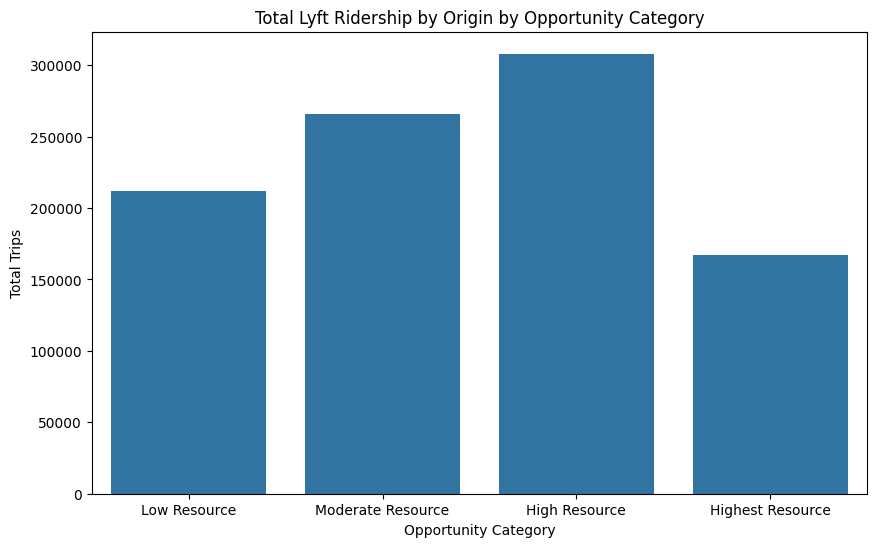

In [ ]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=opp_summary,
    x="oppcat",
    y="Trip Count",
    order=category_order
)

plt.title("Total Lyft Ridership by Origin by Opportunity Category")
plt.xlabel("Opportunity Category")
plt.ylabel("Total Trips")

plt.show()

Graph 2: Average Ridership by Opportunity Category

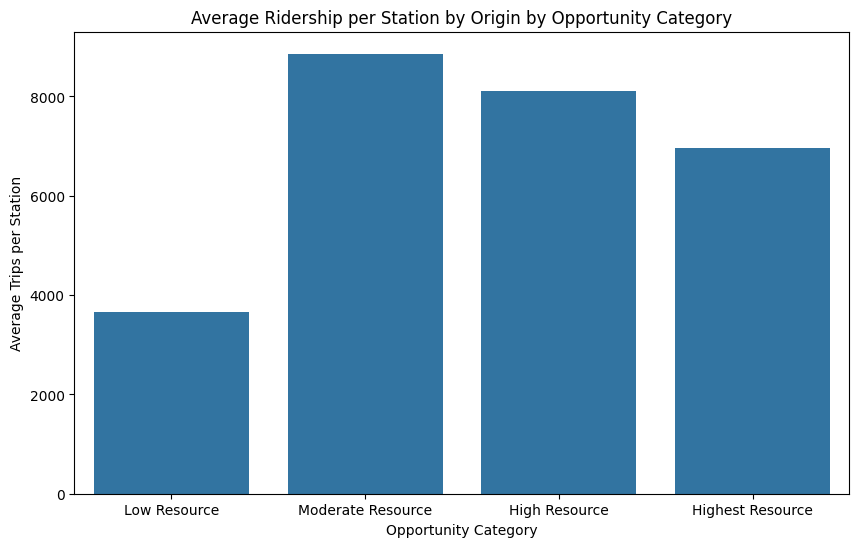

In [ ]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=opp_summary,
    x="oppcat",
    y="avg_trips_per_station",
    order=category_order
)

plt.title("Average Ridership per Station by Origin by Opportunity Category")
plt.xlabel("Opportunity Category")
plt.ylabel("Average Trips per Station")

plt.show()

Graph 3: Ridership vs. Opportunity Score

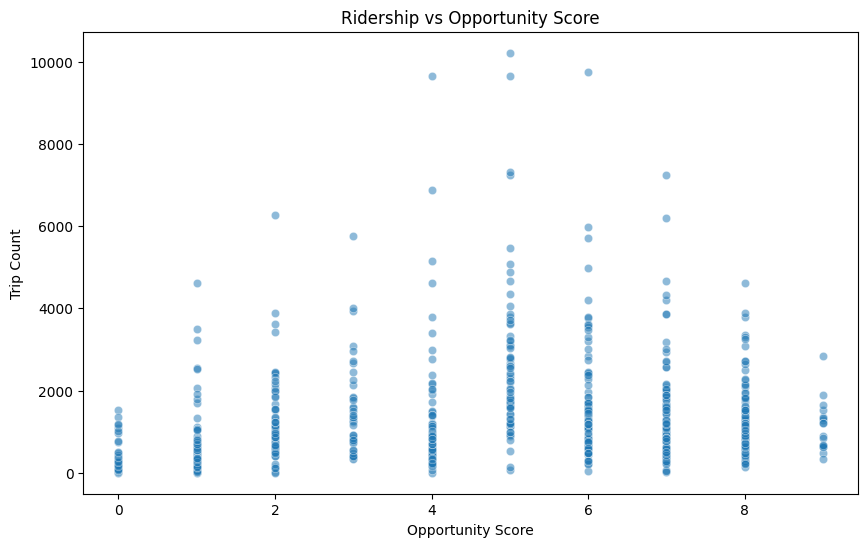

In [ ]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=merged_clean,
    x="oppscore",
    y="Trip Count",
    alpha=0.5
)

plt.title("Ridership vs Opportunity Score")
plt.xlabel("Opportunity Score")
plt.ylabel("Trip Count")

plt.show()

Graph 4: Ridership Trends

Regression of average by score

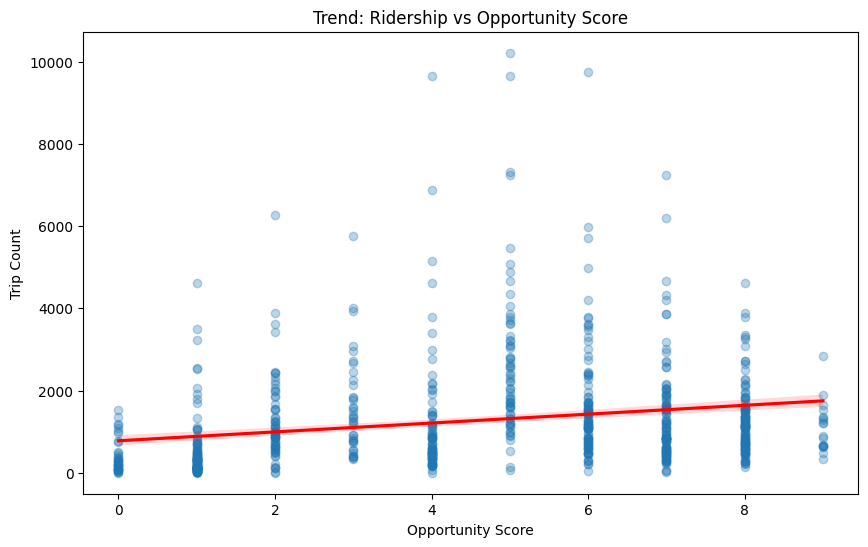

In [ ]:
plt.figure(figsize=(10, 6))

sns.regplot(
    data=merged_clean,
    x="oppscore",
    y="Trip Count",
    scatter_kws={"alpha": 0.3},
    line_kws={"color": "red"}
)

plt.title("Trend: Ridership vs Opportunity Score")
plt.xlabel("Opportunity Score")
plt.ylabel("Trip Count")

plt.show()

In [ ]:
regression = px.scatter( #plotly scatter plot. Compared to my other visualizations, the scatter plot most accurately portrays my data in a visually informative format.
    merged_clean,
    x="oppscore",
    y="Trip Count",
    opacity=0.3,
    trendline="ols",  # adds regression line
    title="Trend: Ridership vs Opportunity Score"
)

regression.update_layout( #adds regression, necessary to understand if there is a trend or not between ridership levels and opp score
    xaxis_title="Opportunity Score",
    yaxis_title="Trip Count"
)

regression.update_traces(
    line=dict(color="red"), #red for visual clarity but can be whatever color
    selector=dict(mode="lines")
)

regression.show()

In [ ]:
# # Remove hashes to download
# regression.write_html("ridership_vs_opportunity.html")

# from google.colab import files
# files.download("ridership_vs_opportunity.html")

Graph 5: Ridership by Year and Opportunity Category

In [ ]:
#Creates average with year and opportunity category
year_cat_summary = merged_clean.groupby(
    ["Year", "oppcat"]
)["Trip Count"].mean().reset_index()

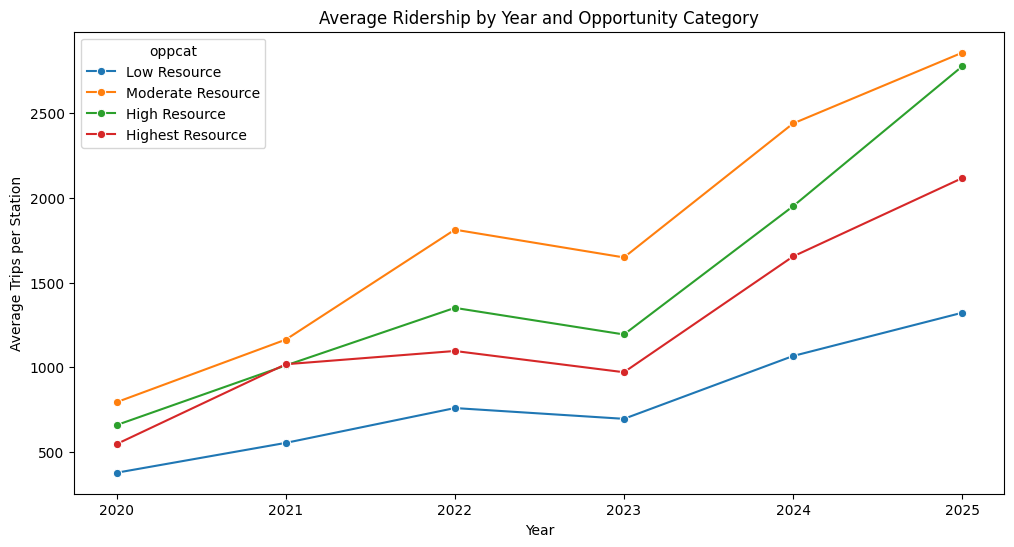

In [ ]:
plt.figure(figsize=(12, 6))

sns.lineplot(
    data=year_cat_summary,
    x="Year",
    y="Trip Count",
    hue="oppcat",
    hue_order=category_order,
    marker="o"
)

plt.title("Average Ridership by Year and Opportunity Category")
plt.ylabel("Average Trips per Station")
plt.xlabel("Year")

plt.show()

In [ ]:
avg_ridership = px.line( #plotly doc for line graphs
    year_cat_summary,
    x="Year",
    y="Trip Count",
    color="oppcat", #bases colors on each oppcat because they are distinctly dif metrics that are being compared
    category_orders={"oppcat": category_order}, #Maintaining the order from low to high to visual representation
    markers=True,
    title="Average Ridership by Year and Opportunity Category"
)

avg_ridership.update_layout(
    xaxis_title="Year",
    yaxis_title="Average Trips per Station"
)

avg_ridership.show()

In [ ]:
# # Remove Hashes to download
# avg_ridership.write_html("ridership_by_year_category.html")

# from google.colab import files
# files.download("ridership_by_year_category.html")